# PDF-Exact Three-Stage Model

This notebook follows the Task 7, Task 8, and Task 9 PDFs directly. It is intentionally self-contained so the model definitions, training settings, sweep settings, routing rules, and output layout are all explicit inside the notebook.

Outputs are written to `outputs/3_stage_model/` with one folder per sweep run such as `N_2`, `N_4`, `N_6`, `N_8`, and `N_10`.

In [4]:
from __future__ import annotations

import json
import math
import random
import sys
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from measurements import (
    GridSpec,
    add_gaussian_noise,
    build_measurement_matrix,
    coefficients_to_feature_vector,
    compute_coefficients,
    compute_gradient_data,
    condition_number,
    create_grid,
    measurement_points_on_unit_circle,
    measurements_to_feature_vector,
)
from models.metrics import binary_iou
from shapes import AnnulusSpec, CircleSpec, EllipseSpec, RectangleSpec, TwoCirclesSpec

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

OUTPUT_ROOT = ROOT / 'outputs' / '3_stage_model'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


N_values = [2, 4, 6, 8, 10]
training_sizes = [2000, 4000, 6000, 8000, 10000]
validation_sizes = [500, 800, 1200, 1600, 2000]

TASK7_SHARED = {
    'rho': 0.8,
    'grid_size': 32,
    'test_samples': 500,
    'threshold': 0.5,
    'noise_level': 0.01,
}

TASK8_STAGE1 = {
    'hidden_dims': (128, 256, 128),
    'dropout_rates': (0.2, 0.2),
    'epochs': 200,
    'batch_size': 32,
    'learning_rate': 0.0005,
    'validation_frequency': 10,
    'early_stopping_patience': 10,
}

TASK9_GENERAL = {
    'hidden_dims': (512, 1024, 2048),
    'dropout_rate': 0.2,
    'edge_weight': 3.0,
    'edge_width': 2,
    'rectangle_augmentation_copies': 2,
    'dice_loss_weight': 0.5,
    'epochs': 150,
    'batch_size': 64,
    'learning_rate': 0.001,
    'validation_frequency': 30,
    'lr_drop_factor': 0.5,
    'lr_drop_period': 50,
    'weight_decay': 0.0001,
    'gradient_clip_norm': 1.0,
    'early_stopping_patience': 20,
    'min_epochs': 40,
    'min_improvement': 0.001,
}

TASK9_SPECIALIST = {
    'hidden_dims': (1024, 2048, 4096),
    'dropout_rate': 0.3,
    'dice_loss_weight': 0.5,
    'epochs': 200,
    'batch_size': 32,
    'learning_rate': 0.0005,
    'validation_frequency': 30,
    'lr_drop_factor': 0.5,
    'lr_drop_period': 50,
    'weight_decay': 0.0001,
}

print('Device:', DEVICE)
print('Output root:', OUTPUT_ROOT)
print('Task 7 sweep:', N_values, training_sizes, validation_sizes)
print('Task 8 Stage 1:', TASK8_STAGE1)
print('Task 9 General:', TASK9_GENERAL)
print('Task 9 Specialist:', TASK9_SPECIALIST)

Device: cuda
Output root: c:\Users\prest\Documents\minimal-gravimetry-ml\outputs\3_stage_model
Task 7 sweep: [2, 4, 6, 8, 10] [2000, 4000, 6000, 8000, 10000] [500, 800, 1200, 1600, 2000]
Task 8 Stage 1: {'hidden_dims': (128, 256, 128), 'dropout_rates': (0.2, 0.2), 'epochs': 200, 'batch_size': 32, 'learning_rate': 0.0005, 'validation_frequency': 10, 'early_stopping_patience': 10}
Task 9 General: {'hidden_dims': (512, 1024, 2048), 'dropout_rate': 0.2, 'edge_weight': 3.0, 'edge_width': 2, 'rectangle_augmentation_copies': 2, 'dice_loss_weight': 0.5, 'epochs': 150, 'batch_size': 64, 'learning_rate': 0.001, 'validation_frequency': 30, 'lr_drop_factor': 0.5, 'lr_drop_period': 50, 'weight_decay': 0.0001, 'gradient_clip_norm': 1.0, 'early_stopping_patience': 20, 'min_epochs': 40, 'min_improvement': 0.001}
Task 9 Specialist: {'hidden_dims': (1024, 2048, 4096), 'dropout_rate': 0.3, 'dice_loss_weight': 0.5, 'epochs': 200, 'batch_size': 32, 'learning_rate': 0.0005, 'validation_frequency': 30, 'lr_d

In [5]:
@dataclass
class SplitData:
    gradient_data: np.ndarray
    coefficients: np.ndarray
    masks: np.ndarray
    shape_types: tuple[str, ...]
    names: tuple[str, ...]
    shapes: tuple[object, ...]


def task7_shape_probabilities(n_value: int) -> tuple[tuple[str, float], ...]:
    if n_value >= 6:
        return (
            ('two_circles', 0.45),
            ('annulus', 0.10),
            ('rectangle', 0.25),
            ('ellipse', 0.15),
            ('circle', 0.05),
        )
    return (
        ('two_circles', 0.45),
        ('annulus', 0.10),
        ('rectangle', 0.20),
        ('ellipse', 0.15),
        ('circle', 0.10),
    )


def random_center(rng: np.random.Generator, scale: float) -> tuple[float, float]:
    values = (2.0 * rng.random(2) - 1.0) * scale
    return float(values[0]), float(values[1])


def generate_ellipse(rng: np.random.Generator, rho: float):
    return EllipseSpec(
        a=float(rng.uniform(0.2, 0.8)),
        b=float(rng.uniform(0.1, 0.6)),
        theta=float(rng.uniform(0.0, np.pi)),
        center=random_center(rng, rho * 0.8),
    )


def generate_annulus(rng: np.random.Generator, rho: float):
    outer_radius = float(rng.uniform(0.3, 0.8))
    inner_radius = float(rng.uniform(0.05, 0.4))
    if inner_radius >= outer_radius:
        inner_radius = outer_radius * 0.5
    return AnnulusSpec(outer_radius=outer_radius, inner_radius=inner_radius, center=random_center(rng, rho * 0.6))


def generate_rectangle(rng: np.random.Generator, rho: float):
    return RectangleSpec(
        width=float(rng.uniform(0.2, 0.9)),
        height=float(rng.uniform(0.2, 0.7)),
        theta=float(rng.uniform(0.0, np.pi)),
        center=random_center(rng, rho * 0.8),
    )


def generate_two_circles(rng: np.random.Generator, rho: float):
    return TwoCirclesSpec(
        radius1=float(rng.uniform(0.1, 0.35)),
        center1=random_center(rng, rho * 0.8),
        radius2=float(rng.uniform(0.1, 0.35)),
        center2=random_center(rng, rho * 0.8),
    )


def sample_task7_shape(n_value: int, rho: float, rng: np.random.Generator):
    draw = float(rng.random())
    cumulative = 0.0
    for shape_type, weight in task7_shape_probabilities(n_value):
        cumulative += weight
        if draw < cumulative:
            if shape_type == 'two_circles':
                return generate_two_circles(rng, rho)
            if shape_type == 'annulus':
                return generate_annulus(rng, rho)
            if shape_type == 'rectangle':
                return generate_rectangle(rng, rho)
            if shape_type == 'ellipse':
                return generate_ellipse(rng, rho)
            return CircleSpec(radius=0.5, center=random_center(rng, 0.8))
    return CircleSpec(radius=0.5, center=random_center(rng, 0.8))


def create_task7_fixed_shapes():
    shapes = [
        EllipseSpec(a=0.6, b=0.3, theta=np.pi / 4.0, center=(0.1, 0.1)),
        EllipseSpec(a=0.5, b=0.5, theta=0.0, center=(-0.1, -0.1)),
        AnnulusSpec(outer_radius=0.7, inner_radius=0.3, center=(0.0, 0.0)),
        RectangleSpec(width=0.8, height=0.4, theta=np.pi / 6.0, center=(0.2, -0.1)),
        TwoCirclesSpec(radius1=0.3, center1=(-0.4, 0.3), radius2=0.25, center2=(0.4, -0.2)),
    ]
    names = (
        'Ellipse (a=0.6, b=0.3, theta=45)',
        'Circle (radius=0.5)',
        'Annulus (R=0.7, r=0.3)',
        'Rectangle (0.8 x 0.4, theta=30)',
        'Two Disconnected Circles',
    )
    return shapes, names


def build_split(sample_count: int, config: dict, grid, measurement_points, rng: np.random.Generator, fixed_shapes=None, fixed_names=None):
    gradient_rows = []
    coefficient_rows = []
    mask_rows = []
    shape_types = []
    names = []
    shapes = []

    if fixed_shapes is None:
        entries = [(None, sample_task7_shape(config['N'], config['rho'], rng)) for _ in range(sample_count)]
    else:
        entries = list(zip(fixed_names, fixed_shapes))

    for display_name, shape in entries:
        mask = shape.compute_mask(grid.X, grid.Y).astype(np.float32)
        coeff = compute_coefficients(mask, grid.X, grid.Y, grid.dA, n_max=config['N']).coefficients
        grad = compute_gradient_data(coeff, measurement_points, config['N'])
        noisy_grad = add_gaussian_noise(grad, config['noise_level'], rng)

        gradient_rows.append(measurements_to_feature_vector(noisy_grad))
        coefficient_rows.append(coefficients_to_feature_vector(coeff))
        mask_rows.append(mask.reshape(-1))
        shape_types.append(shape.type)
        names.append(display_name or shape.type)
        shapes.append(shape)

    return SplitData(
        gradient_data=np.stack(gradient_rows).astype(np.float32),
        coefficients=np.stack(coefficient_rows).astype(np.float32),
        masks=np.stack(mask_rows).astype(np.float32),
        shape_types=tuple(shape_types),
        names=tuple(names),
        shapes=tuple(shapes),
    )


def build_task7_datasets(config: dict):
    rng = np.random.default_rng(config['seed'])
    grid = create_grid(GridSpec(grid_size=config['grid_size']))
    measurement_points = measurement_points_on_unit_circle(config['N'] + 1)
    measurement_matrix = build_measurement_matrix(measurement_points, config['N'])
    fixed_shapes, fixed_names = create_task7_fixed_shapes()
    return {
        'grid': grid,
        'measurement_points': measurement_points,
        'measurement_matrix': measurement_matrix,
        'condition_number': float(condition_number(measurement_matrix)),
        'train': build_split(config['training_samples'], config, grid, measurement_points, rng),
        'validation': build_split(config['validation_samples'], config, grid, measurement_points, rng),
        'test': build_split(config['test_samples'], config, grid, measurement_points, rng),
        'fixed': build_split(len(fixed_shapes), config, grid, measurement_points, rng, fixed_shapes=fixed_shapes, fixed_names=fixed_names),
    }


def clamp_center(center):
    return float(max(-0.9, min(0.9, center[0]))), float(max(-0.9, min(0.9, center[1])))


def sample_specialist_two_circles(rng: np.random.Generator):
    draw = float(rng.random())
    if draw < 0.25:
        regime = 'separated'
        radius1 = float(0.15 + 0.3 * rng.random())
        radius2 = float(0.15 + 0.3 * rng.random())
        center1 = (-0.5 + 0.3 * float(rng.random()), -0.3 + 0.6 * float(rng.random()))
        min_dist = radius1 + radius2 + 0.2
        distance = min_dist + 0.3 * float(rng.random())
    elif draw < 0.50:
        regime = 'touching'
        radius1 = float(0.2 + 0.3 * rng.random())
        radius2 = float(0.2 + 0.3 * rng.random())
        center1 = (-0.4 + 0.3 * float(rng.random()), -0.3 + 0.6 * float(rng.random()))
        distance = radius1 + radius2 + 0.02 * float(rng.random())
    elif draw < 0.75:
        regime = 'overlapping'
        radius1 = float(0.25 + 0.3 * rng.random())
        radius2 = float(0.25 + 0.3 * rng.random())
        center1 = (-0.3 + 0.3 * float(rng.random()), -0.3 + 0.6 * float(rng.random()))
        overlap = float(0.7 + 0.2 * rng.random())
        distance = (radius1 + radius2) * overlap
    else:
        regime = 'nested'
        radius1 = float(0.3 + 0.3 * rng.random())
        radius2 = float(0.1 + 0.2 * rng.random())
        center1 = (-0.2 + 0.4 * float(rng.random()), -0.2 + 0.4 * float(rng.random()))
        distance = (radius1 - radius2) * 0.5 * float(rng.random())
    angle = 2.0 * np.pi * float(rng.random())
    center2 = (center1[0] + distance * float(np.cos(angle)), center1[1] + distance * float(np.sin(angle)))
    return regime, TwoCirclesSpec(radius1=radius1, center1=clamp_center(center1), radius2=radius2, center2=clamp_center(center2))


def build_specialist_dataset(config: dict):
    rng = np.random.default_rng(config['seed'] + 1000)
    grid = create_grid(GridSpec(grid_size=config['grid_size']))
    measurement_points = measurement_points_on_unit_circle(config['N'] + 1)

    def _make_split(sample_count: int, prefix: str):
        gradient_rows = []
        coefficient_rows = []
        mask_rows = []
        shape_types = []
        names = []
        shapes = []
        for index in range(sample_count):
            regime, shape = sample_specialist_two_circles(rng)
            mask = shape.compute_mask(grid.X, grid.Y).astype(np.float32)
            coeff = compute_coefficients(mask, grid.X, grid.Y, grid.dA, n_max=config['N']).coefficients
            grad = compute_gradient_data(coeff, measurement_points, config['N'])
            gradient_rows.append(measurements_to_feature_vector(grad))
            coefficient_rows.append(coefficients_to_feature_vector(coeff))
            mask_rows.append(mask.reshape(-1))
            shape_types.append(shape.type)
            names.append(f'{prefix}_{regime}_{index}')
            shapes.append(shape)
        return SplitData(
            gradient_data=np.stack(gradient_rows).astype(np.float32),
            coefficients=np.stack(coefficient_rows).astype(np.float32),
            masks=np.stack(mask_rows).astype(np.float32),
            shape_types=tuple(shape_types),
            names=tuple(names),
            shapes=tuple(shapes),
        )

    return {
        'train': _make_split(config['training_samples'], 'train'),
        'validation': _make_split(config['validation_samples'], 'validation'),
    }


def compute_stats(values: np.ndarray):
    mean = values.mean(axis=0)
    std = values.std(axis=0)
    std = np.where(std == 0, 1.0, std)
    return mean.astype(np.float32), std.astype(np.float32)


def normalize(values: np.ndarray, mean: np.ndarray, std: np.ndarray):
    return ((values - mean) / std).astype(np.float32)


class Stage1DNN(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
        )

    def forward(self, inputs):
        return self.network(inputs)


class MaskMLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_dims: tuple[int, ...], dropout_rate: float):
        super().__init__()
        layers = []
        previous = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([nn.Linear(previous, hidden_dim), nn.ReLU(), nn.Dropout(dropout_rate)])
            previous = hidden_dim
        layers.append(nn.Linear(previous, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs)


def sigmoid_numpy(logits: np.ndarray):
    return 1.0 / (1.0 + np.exp(-logits))


def compute_loss(predictions: torch.Tensor, targets: torch.Tensor, sample_weights: torch.Tensor | None = None, *, loss_name: str = 'mse', dice_loss_weight: float = 0.0):
    if loss_name == 'mse':
        squared_error = (predictions - targets) ** 2
        if sample_weights is not None:
            squared_error = squared_error * sample_weights
        return squared_error.mean()

    bce = torch.nn.functional.binary_cross_entropy_with_logits(predictions, targets, reduction='none')
    if sample_weights is not None:
        bce = bce * sample_weights
    loss = bce.mean()
    if dice_loss_weight > 0.0:
        probabilities = torch.sigmoid(predictions)
        if sample_weights is not None:
            intersection = (sample_weights * probabilities * targets).sum(dim=1)
            denominator = (sample_weights * probabilities).sum(dim=1) + (sample_weights * targets).sum(dim=1)
        else:
            intersection = (probabilities * targets).sum(dim=1)
            denominator = probabilities.sum(dim=1) + targets.sum(dim=1)
        dice_score = (2.0 * intersection + 1.0) / (denominator + 1.0)
        loss = loss + dice_loss_weight * (1.0 - dice_score.mean())
    return loss


def dilate_binary_mask(mask: np.ndarray, radius: int) -> np.ndarray:
    dilated = np.zeros_like(mask, dtype=bool)
    for dx in range(-radius, radius + 1):
        for dy in range(-radius, radius + 1):
            if dx * dx + dy * dy > radius * radius:
                continue
            src_x_start = max(0, -dx)
            src_x_end = mask.shape[0] - max(0, dx)
            src_y_start = max(0, -dy)
            src_y_end = mask.shape[1] - max(0, dy)
            dst_x_start = max(0, dx)
            dst_x_end = dst_x_start + (src_x_end - src_x_start)
            dst_y_start = max(0, dy)
            dst_y_end = dst_y_start + (src_y_end - src_y_start)
            dilated[dst_x_start:dst_x_end, dst_y_start:dst_y_end] |= mask[src_x_start:src_x_end, src_y_start:src_y_end]
    return dilated


def compute_rectangle_pixel_weights(masks: np.ndarray, shape_types: tuple[str, ...], grid_size: int, edge_weight: float, edge_width: int):
    pixel_weights = np.ones_like(masks, dtype=np.float32)
    for index, shape_type in enumerate(shape_types):
        if shape_type != 'rectangle':
            continue
        mask = masks[index].reshape(grid_size, grid_size)
        gx, gy = np.gradient(mask.astype(np.float32))
        edges = np.sqrt(gx ** 2 + gy ** 2) > 0.1
        edge_region = dilate_binary_mask(edges, edge_width)
        weight_map = np.ones_like(mask, dtype=np.float32)
        weight_map[edge_region] = edge_weight
        pixel_weights[index] = weight_map.reshape(-1)
    return pixel_weights


def augment_rectangles(features: np.ndarray, masks: np.ndarray, shape_types: tuple[str, ...], names: tuple[str, ...], copies: int):
    rectangle_indices = [index for index, shape_type in enumerate(shape_types) if shape_type == 'rectangle']
    if not rectangle_indices or copies <= 0:
        return features, masks, shape_types, names
    feature_rows = [features]
    mask_rows = [masks]
    aug_shape_types = list(shape_types)
    aug_names = list(names)
    for copy_index in range(copies):
        feature_rows.append(features[rectangle_indices])
        mask_rows.append(masks[rectangle_indices])
        aug_shape_types.extend(shape_types[index] for index in rectangle_indices)
        aug_names.extend(f'{names[index]}_rectangle_copy_{copy_index + 1}' for index in rectangle_indices)
    return np.concatenate(feature_rows, axis=0), np.concatenate(mask_rows, axis=0), tuple(aug_shape_types), tuple(aug_names)


def build_loader(features: np.ndarray, targets: np.ndarray, batch_size: int, shuffle: bool, sample_weights: np.ndarray | None = None):
    tensors = [torch.tensor(features, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)]
    if sample_weights is not None:
        tensors.append(torch.tensor(sample_weights, dtype=torch.float32))
    return DataLoader(TensorDataset(*tensors), batch_size=batch_size, shuffle=shuffle)


def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, *, epochs: int, learning_rate: float, validation_frequency: int, weight_decay: float = 0.0, gradient_clip_norm: float | None = None, early_stopping_patience: int | None = None, min_epochs: int | None = None, min_improvement: float | None = None, lr_drop_factor: float | None = None, lr_drop_period: int | None = None, loss_name: str = 'mse', dice_loss_weight: float = 0.0):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = None
    if lr_drop_factor is not None and lr_drop_period is not None:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_drop_period, gamma=lr_drop_factor)
    history = {'train_loss': [], 'val_loss': [], 'validation_steps': []}
    best_val = float('inf')
    best_state = None
    wait_count = 0
    global_step = 0

    def evaluate_loader(current_model):
        current_model.eval()
        losses = []
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch[0].to(DEVICE)
                targets = batch[1].to(DEVICE)
                weights = batch[2].to(DEVICE) if len(batch) > 2 else None
                predictions = current_model(inputs)
                losses.append(float(compute_loss(predictions, targets, weights, loss_name=loss_name, dice_loss_weight=dice_loss_weight).detach().cpu().item()))
        return float(np.mean(losses))

    epochs_trained = 0
    for epoch_index in range(epochs):
        model.train()
        train_losses = []
        validated_this_epoch = False
        epoch_best_val = float('inf')
        previous_best_val = best_val
        for batch in train_loader:
            inputs = batch[0].to(DEVICE)
            targets = batch[1].to(DEVICE)
            weights = batch[2].to(DEVICE) if len(batch) > 2 else None
            optimizer.zero_grad()
            predictions = model(inputs)
            loss = compute_loss(predictions, targets, weights, loss_name=loss_name, dice_loss_weight=dice_loss_weight)
            loss.backward()
            if gradient_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_norm)
            optimizer.step()
            train_losses.append(float(loss.detach().cpu().item()))
            global_step += 1

            if validation_frequency and global_step % validation_frequency == 0:
                val_loss = evaluate_loader(model)
                history['val_loss'].append(val_loss)
                history['validation_steps'].append(global_step)
                validated_this_epoch = True
                epoch_best_val = min(epoch_best_val, val_loss)
                if val_loss < best_val:
                    best_val = val_loss
                    best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

        history['train_loss'].append(float(np.mean(train_losses)))
        if not validated_this_epoch:
            val_loss = evaluate_loader(model)
            history['val_loss'].append(val_loss)
            history['validation_steps'].append(global_step)
            epoch_best_val = val_loss
            if val_loss < best_val:
                best_val = val_loss
                best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

        meets_epoch_floor = min_epochs is None or (epoch_index + 1) >= min_epochs
        required_improvement = min_improvement or 0.0
        improvement_fraction = float('inf') if not math.isfinite(previous_best_val) or previous_best_val == 0 else (previous_best_val - epoch_best_val) / previous_best_val
        improved_this_epoch = epoch_best_val < previous_best_val and improvement_fraction >= required_improvement
        if improved_this_epoch:
            wait_count = 0
        elif meets_epoch_floor:
            wait_count += 1
        if scheduler is not None:
            scheduler.step()
        epochs_trained = epoch_index + 1
        if early_stopping_patience is not None and wait_count >= early_stopping_patience and meets_epoch_floor:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    history['epochs_trained'] = epochs_trained
    return model, history


def predict_numpy(model: nn.Module, features: np.ndarray, batch_size: int = 256) -> np.ndarray:
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, features.shape[0], batch_size):
            batch = torch.tensor(features[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            outputs.append(model(batch).detach().cpu().numpy())
    return np.concatenate(outputs, axis=0)


def evaluate_masks(y_true: np.ndarray, logits: np.ndarray, threshold: float):
    probabilities = sigmoid_numpy(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    ious = [binary_iou(true_row, pred_row) for true_row, pred_row in zip(y_true, binary_predictions, strict=False)]
    pixel_accuracy = float(np.mean(binary_predictions == y_true))
    return {'mean_iou': float(np.mean(ious)), 'pixel_accuracy': pixel_accuracy}, np.array(ious, dtype=np.float32), probabilities


def plot_history(history: dict, title: str, output_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(np.arange(1, len(history['train_loss']) + 1), history['train_loss'], marker='o')
    axes[0].set_title(f'{title} Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['validation_steps'], history['val_loss'], marker='o', color='tab:orange')
    axes[1].set_title(f'{title} Validation Loss')
    axes[1].set_xlabel('Validation Step')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def save_fixed_gallery(true_masks: np.ndarray, names: tuple[str, ...], grid_size: int, output_path: Path):
    fig, axes = plt.subplots(1, len(names), figsize=(15, 3))
    for axis, name, mask in zip(axes, names, true_masks, strict=False):
        axis.imshow(mask.reshape(grid_size, grid_size), cmap='gray', origin='lower')
        axis.set_title(name)
        axis.axis('off')
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def save_prediction_gallery(true_masks: np.ndarray, predicted_masks: np.ndarray, names: tuple[str, ...], grid_size: int, output_path: Path, title_suffix: str):
    fig, axes = plt.subplots(2, len(names), figsize=(15, 6))
    for index, name in enumerate(names):
        axes[0, index].imshow(true_masks[index].reshape(grid_size, grid_size), cmap='gray', origin='lower')
        axes[0, index].set_title(name)
        axes[0, index].axis('off')
        axes[1, index].imshow(predicted_masks[index].reshape(grid_size, grid_size), cmap='gray', origin='lower')
        axes[1, index].axis('off')
    axes[0, 0].set_ylabel('True')
    axes[1, 0].set_ylabel(title_suffix)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def save_test_comparison(true_masks: np.ndarray, general_logits: np.ndarray, combined_logits: np.ndarray, grid_size: int, output_path: Path):
    general_metrics, general_ious, general_probs = evaluate_masks(true_masks, general_logits, TASK7_SHARED['threshold'])
    combined_metrics, combined_ious, combined_probs = evaluate_masks(true_masks, combined_logits, TASK7_SHARED['threshold'])
    best_indices = np.argsort(combined_ious)[-3:][::-1]
    fig, axes = plt.subplots(len(best_indices), 3, figsize=(9, 9))
    if len(best_indices) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row, index in enumerate(best_indices):
        axes[row, 0].imshow(true_masks[index].reshape(grid_size, grid_size), cmap='gray', origin='lower')
        axes[row, 0].set_title('True')
        axes[row, 1].imshow((general_probs[index] >= TASK7_SHARED['threshold']).reshape(grid_size, grid_size), cmap='gray', origin='lower')
        axes[row, 1].set_title(f'General IoU={general_ious[index]:.3f}')
        axes[row, 2].imshow((combined_probs[index] >= TASK7_SHARED['threshold']).reshape(grid_size, grid_size), cmap='gray', origin='lower')
        axes[row, 2].set_title(f'Combined IoU={combined_ious[index]:.3f}')
        for column in range(3):
            axes[row, column].axis('off')
    fig.suptitle(f"Test comparison | General IoU={general_metrics['mean_iou']:.3f} | Combined IoU={combined_metrics['mean_iou']:.3f}")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def annulus_center_diagnostics(probabilities: np.ndarray, grid_size: int):
    center_slice = slice(grid_size // 2 - 4, grid_size // 2 + 4)
    center = probabilities.reshape(grid_size, grid_size)[center_slice, center_slice]
    return {
        'center_mean_probability': float(center.mean()),
        'center_max_probability': float(center.max()),
        'center_min_probability': float(center.min()),
    }


Running N=2 -> c:\Users\prest\Documents\minimal-gravimetry-ml\outputs\3_stage_model\N_2
Running N=4 -> c:\Users\prest\Documents\minimal-gravimetry-ml\outputs\3_stage_model\N_4
Running N=6 -> c:\Users\prest\Documents\minimal-gravimetry-ml\outputs\3_stage_model\N_6
Running N=8 -> c:\Users\prest\Documents\minimal-gravimetry-ml\outputs\3_stage_model\N_8
Running N=10 -> c:\Users\prest\Documents\minimal-gravimetry-ml\outputs\3_stage_model\N_10


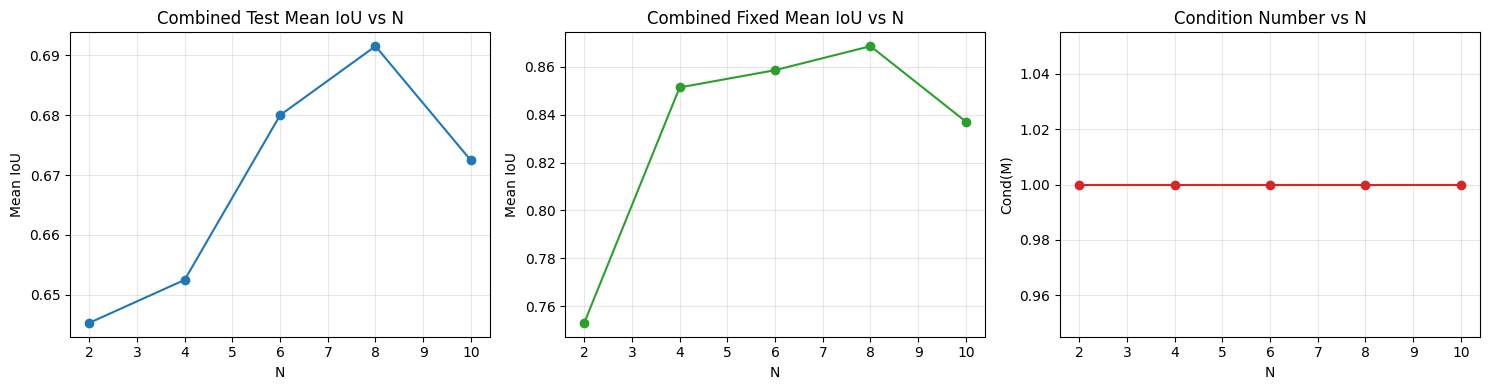

[{'N': 2,
  'training_samples': 2000,
  'validation_samples': 500,
  'test_samples': 500,
  'condition_number': 1.0000000000000004,
  'stage1': {'train_mse': 8.283464012492914e-06,
   'val_mse': 7.454470960510662e-06,
   'train_history_final': 0.002112995670546615,
   'val_history_final': 0.001735004705551546,
   'epochs_trained': 44},
  'general': {'test_metrics': {'mean_iou': 0.6453133015130811,
    'pixel_accuracy': 0.96196484375},
   'fixed_metrics': {'mean_iou': 0.7530795081801687,
    'pixel_accuracy': 0.953125},
   'fixed_true_coeff_metrics': {'mean_iou': 0.7945690679572591,
    'pixel_accuracy': 0.9599609375},
   'rectangle_augmentation_added': 842,
   'epochs_trained': 72,
   'annulus_predicted_coeff_diagnostics': {'center_mean_probability': 0.9518024921417236,
    'center_max_probability': 0.9990653395652771,
    'center_min_probability': 0.7292298674583435},
   'annulus_true_coeff_diagnostics': {'center_mean_probability': 0.9535688161849976,
    'center_max_probability': 0.9

In [6]:
sweep_rows = []

for index, n_value in enumerate(N_values):
    run_config = {
        'N': n_value,
        'rho': TASK7_SHARED['rho'],
        'grid_size': TASK7_SHARED['grid_size'],
        'training_samples': training_sizes[index],
        'validation_samples': validation_sizes[index],
        'test_samples': TASK7_SHARED['test_samples'],
        'threshold': TASK7_SHARED['threshold'],
        'noise_level': TASK7_SHARED['noise_level'],
        'seed': SEED + index,
    }
    run_dir = OUTPUT_ROOT / f'N_{n_value}'
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f'Running N={n_value} -> {run_dir}')

    datasets = build_task7_datasets(run_config)
    with (run_dir / 'config.json').open('w', encoding='utf-8') as handle:
        json.dump({
            'run_config': run_config,
            'task7_shape_probabilities': task7_shape_probabilities(n_value),
            'stage1_task8': TASK8_STAGE1,
            'general_task9': TASK9_GENERAL,
            'specialist_task9': TASK9_SPECIALIST,
            'condition_number': datasets['condition_number'],
        }, handle, indent=2)

    stage1_x_mu, stage1_x_sigma = compute_stats(datasets['train'].gradient_data)
    stage1_y_mu, stage1_y_sigma = compute_stats(datasets['train'].coefficients)
    stage1_train_x = normalize(datasets['train'].gradient_data, stage1_x_mu, stage1_x_sigma)
    stage1_val_x = normalize(datasets['validation'].gradient_data, stage1_x_mu, stage1_x_sigma)
    stage1_train_y = normalize(datasets['train'].coefficients, stage1_y_mu, stage1_y_sigma)
    stage1_val_y = normalize(datasets['validation'].coefficients, stage1_y_mu, stage1_y_sigma)

    stage1_model = Stage1DNN(input_dim=stage1_train_x.shape[1], output_dim=stage1_train_y.shape[1])
    stage1_model, stage1_history = train_model(
        stage1_model,
        build_loader(stage1_train_x, stage1_train_y, TASK8_STAGE1['batch_size'], True),
        build_loader(stage1_val_x, stage1_val_y, TASK8_STAGE1['batch_size'], False),
        epochs=TASK8_STAGE1['epochs'],
        learning_rate=TASK8_STAGE1['learning_rate'],
        validation_frequency=TASK8_STAGE1['validation_frequency'],
        early_stopping_patience=TASK8_STAGE1['early_stopping_patience'],
        loss_name='mse',
    )
    plot_history(stage1_history, 'Task 8 Stage 1', run_dir / 'stage1_losses.png')

    def stage1_predict(features: np.ndarray):
        normalized = normalize(features, stage1_x_mu, stage1_x_sigma)
        pred_norm = predict_numpy(stage1_model, normalized)
        return pred_norm * stage1_y_sigma + stage1_y_mu

    train_pred_coeff = stage1_predict(datasets['train'].gradient_data)
    val_pred_coeff = stage1_predict(datasets['validation'].gradient_data)
    test_pred_coeff = stage1_predict(datasets['test'].gradient_data)
    fixed_pred_coeff = stage1_predict(datasets['fixed'].gradient_data)

    general_train_x_mu, general_train_x_sigma = compute_stats(train_pred_coeff)
    general_train_x = normalize(train_pred_coeff, general_train_x_mu, general_train_x_sigma)
    general_val_x = normalize(val_pred_coeff, general_train_x_mu, general_train_x_sigma)
    general_test_x = normalize(test_pred_coeff, general_train_x_mu, general_train_x_sigma)
    general_fixed_x = normalize(fixed_pred_coeff, general_train_x_mu, general_train_x_sigma)

    general_train_x_aug, general_train_y_aug, general_shape_types_aug, general_names_aug = augment_rectangles(
        general_train_x,
        datasets['train'].masks,
        datasets['train'].shape_types,
        datasets['train'].names,
        TASK9_GENERAL['rectangle_augmentation_copies'],
    )
    general_weights = compute_rectangle_pixel_weights(
        general_train_y_aug,
        general_shape_types_aug,
        run_config['grid_size'],
        TASK9_GENERAL['edge_weight'],
        TASK9_GENERAL['edge_width'],
    )

    general_model = MaskMLP(
        input_dim=general_train_x_aug.shape[1],
        output_dim=general_train_y_aug.shape[1],
        hidden_dims=TASK9_GENERAL['hidden_dims'],
        dropout_rate=TASK9_GENERAL['dropout_rate'],
    )
    general_model, general_history = train_model(
        general_model,
        build_loader(general_train_x_aug, general_train_y_aug, TASK9_GENERAL['batch_size'], True, general_weights),
        build_loader(general_val_x, datasets['validation'].masks, TASK9_GENERAL['batch_size'], False),
        epochs=TASK9_GENERAL['epochs'],
        learning_rate=TASK9_GENERAL['learning_rate'],
        validation_frequency=TASK9_GENERAL['validation_frequency'],
        weight_decay=TASK9_GENERAL['weight_decay'],
        gradient_clip_norm=TASK9_GENERAL['gradient_clip_norm'],
        early_stopping_patience=TASK9_GENERAL['early_stopping_patience'],
        min_epochs=TASK9_GENERAL['min_epochs'],
        min_improvement=TASK9_GENERAL['min_improvement'],
        lr_drop_factor=TASK9_GENERAL['lr_drop_factor'],
        lr_drop_period=TASK9_GENERAL['lr_drop_period'],
        loss_name='bce',
        dice_loss_weight=TASK9_GENERAL['dice_loss_weight'],
    )
    plot_history(general_history, 'Task 9 General', run_dir / 'general_losses.png')

    specialist_model = None
    specialist_history = None
    specialist_x_mu = None
    specialist_x_sigma = None
    if n_value >= 4:
        specialist_dataset = build_specialist_dataset(run_config)
        specialist_train_coeff = stage1_predict(specialist_dataset['train'].gradient_data)
        specialist_val_coeff = stage1_predict(specialist_dataset['validation'].gradient_data)
        specialist_x_mu, specialist_x_sigma = compute_stats(specialist_train_coeff)
        specialist_train_x = normalize(specialist_train_coeff, specialist_x_mu, specialist_x_sigma)
        specialist_val_x = normalize(specialist_val_coeff, specialist_x_mu, specialist_x_sigma)

        specialist_model = MaskMLP(
            input_dim=specialist_train_x.shape[1],
            output_dim=specialist_dataset['train'].masks.shape[1],
            hidden_dims=TASK9_SPECIALIST['hidden_dims'],
            dropout_rate=TASK9_SPECIALIST['dropout_rate'],
        )
        specialist_model, specialist_history = train_model(
            specialist_model,
            build_loader(specialist_train_x, specialist_dataset['train'].masks, TASK9_SPECIALIST['batch_size'], True),
            build_loader(specialist_val_x, specialist_dataset['validation'].masks, TASK9_SPECIALIST['batch_size'], False),
            epochs=TASK9_SPECIALIST['epochs'],
            learning_rate=TASK9_SPECIALIST['learning_rate'],
            validation_frequency=TASK9_SPECIALIST['validation_frequency'],
            weight_decay=TASK9_SPECIALIST['weight_decay'],
            lr_drop_factor=TASK9_SPECIALIST['lr_drop_factor'],
            lr_drop_period=TASK9_SPECIALIST['lr_drop_period'],
            loss_name='bce',
            dice_loss_weight=TASK9_SPECIALIST['dice_loss_weight'],
        )
        plot_history(specialist_history, 'Task 9 Specialist', run_dir / 'specialist_losses.png')

    general_test_logits = predict_numpy(general_model, general_test_x)
    general_fixed_logits = predict_numpy(general_model, general_fixed_x)
    true_fixed_x = normalize(datasets['fixed'].coefficients, general_train_x_mu, general_train_x_sigma)
    general_fixed_true_coeff_logits = predict_numpy(general_model, true_fixed_x)

    combined_test_logits = general_test_logits.copy()
    combined_fixed_logits = general_fixed_logits.copy()
    specialist_count_test = 0
    specialist_count_fixed = 0
    specialist_better_than_general = False
    if specialist_model is not None:
        general_specialist_val_x = normalize(specialist_val_coeff, general_train_x_mu, general_train_x_sigma)
        general_on_specialist_val_logits = predict_numpy(general_model, general_specialist_val_x)
        specialist_val_logits = predict_numpy(specialist_model, specialist_val_x)
        general_two_circle_metrics, _, _ = evaluate_masks(specialist_dataset['validation'].masks, general_on_specialist_val_logits, run_config['threshold'])
        specialist_two_circle_metrics, _, _ = evaluate_masks(specialist_dataset['validation'].masks, specialist_val_logits, run_config['threshold'])
        specialist_better_than_general = specialist_two_circle_metrics['mean_iou'] > general_two_circle_metrics['mean_iou']
        test_two_circle_indices = [i for i, shape_type in enumerate(datasets['test'].shape_types) if shape_type == 'two_circles']
        fixed_two_circle_indices = [i for i, shape_type in enumerate(datasets['fixed'].shape_types) if shape_type == 'two_circles']
        if specialist_better_than_general and test_two_circle_indices:
            specialist_test_x = normalize(test_pred_coeff[test_two_circle_indices], specialist_x_mu, specialist_x_sigma)
            combined_test_logits[test_two_circle_indices] = predict_numpy(specialist_model, specialist_test_x)
            specialist_count_test = len(test_two_circle_indices)
        if specialist_better_than_general and fixed_two_circle_indices:
            specialist_fixed_x = normalize(fixed_pred_coeff[fixed_two_circle_indices], specialist_x_mu, specialist_x_sigma)
            combined_fixed_logits[fixed_two_circle_indices] = predict_numpy(specialist_model, specialist_fixed_x)
            specialist_count_fixed = len(fixed_two_circle_indices)

    stage1_train_mse = float(np.mean((train_pred_coeff - datasets['train'].coefficients) ** 2))
    stage1_val_mse = float(np.mean((val_pred_coeff - datasets['validation'].coefficients) ** 2))
    general_test_metrics, _, general_test_probs = evaluate_masks(datasets['test'].masks, general_test_logits, run_config['threshold'])
    general_fixed_metrics, _, general_fixed_probs = evaluate_masks(datasets['fixed'].masks, general_fixed_logits, run_config['threshold'])
    general_fixed_true_coeff_metrics, _, general_fixed_true_coeff_probs = evaluate_masks(datasets['fixed'].masks, general_fixed_true_coeff_logits, run_config['threshold'])
    combined_test_metrics, _, combined_test_probs = evaluate_masks(datasets['test'].masks, combined_test_logits, run_config['threshold'])
    combined_fixed_metrics, _, combined_fixed_probs = evaluate_masks(datasets['fixed'].masks, combined_fixed_logits, run_config['threshold'])
    annulus_index = datasets['fixed'].names.index('Annulus (R=0.7, r=0.3)')
    annulus_predicted_coeff_diagnostics = annulus_center_diagnostics(general_fixed_probs[annulus_index], run_config['grid_size'])
    annulus_true_coeff_diagnostics = annulus_center_diagnostics(general_fixed_true_coeff_probs[annulus_index], run_config['grid_size'])

    save_fixed_gallery(datasets['fixed'].masks, datasets['fixed'].names, run_config['grid_size'], run_dir / 'fixed_shapes.png')
    save_prediction_gallery(datasets['fixed'].masks, (general_fixed_probs >= run_config['threshold']).astype(np.float32), datasets['fixed'].names, run_config['grid_size'], run_dir / 'fixed_general_predictions.png', 'General')
    save_prediction_gallery(datasets['fixed'].masks, (general_fixed_true_coeff_probs >= run_config['threshold']).astype(np.float32), datasets['fixed'].names, run_config['grid_size'], run_dir / 'fixed_general_true_coeff_predictions.png', 'General True Coeff')
    save_prediction_gallery(datasets['fixed'].masks, (combined_fixed_probs >= run_config['threshold']).astype(np.float32), datasets['fixed'].names, run_config['grid_size'], run_dir / 'fixed_combined_predictions.png', 'Combined')
    save_test_comparison(datasets['test'].masks, general_test_logits, combined_test_logits, run_config['grid_size'], run_dir / 'test_general_vs_combined.png')

    torch.save({
        'state_dict': stage1_model.state_dict(),
        'X_mu': stage1_x_mu,
        'X_sigma': stage1_x_sigma,
        'Y_mu': stage1_y_mu,
        'Y_sigma': stage1_y_sigma,
    }, run_dir / 'stage1_model.pt')
    torch.save({
        'state_dict': general_model.state_dict(),
        'X_mu': general_train_x_mu,
        'X_sigma': general_train_x_sigma,
    }, run_dir / 'task9_general_model.pt')
    if specialist_model is not None:
        torch.save({
            'state_dict': specialist_model.state_dict(),
            'X_mu': specialist_x_mu,
            'X_sigma': specialist_x_sigma,
        }, run_dir / 'task9_specialist_model.pt')

    run_summary = {
        'N': n_value,
        'training_samples': run_config['training_samples'],
        'validation_samples': run_config['validation_samples'],
        'test_samples': run_config['test_samples'],
        'condition_number': datasets['condition_number'],
        'stage1': {
            'train_mse': stage1_train_mse,
            'val_mse': stage1_val_mse,
            'train_history_final': stage1_history['train_loss'][-1],
            'val_history_final': stage1_history['val_loss'][-1],
            'epochs_trained': stage1_history['epochs_trained'],
        },
        'general': {
            'test_metrics': general_test_metrics,
            'fixed_metrics': general_fixed_metrics,
            'fixed_true_coeff_metrics': general_fixed_true_coeff_metrics,
            'rectangle_augmentation_added': int(general_train_x_aug.shape[0] - general_train_x.shape[0]),
            'epochs_trained': general_history['epochs_trained'],
            'annulus_predicted_coeff_diagnostics': annulus_predicted_coeff_diagnostics,
            'annulus_true_coeff_diagnostics': annulus_true_coeff_diagnostics,
        },
        'combined': {
            'test_metrics': combined_test_metrics,
            'fixed_metrics': combined_fixed_metrics,
            'specialist_used_for_test_samples': specialist_count_test,
            'specialist_used_for_fixed_samples': specialist_count_fixed,
            'specialist_better_than_general': bool(specialist_better_than_general),
        },
        'specialist_enabled': bool(n_value >= 4),
    }
    with (run_dir / 'summary.json').open('w', encoding='utf-8') as handle:
        json.dump(run_summary, handle, indent=2)
    sweep_rows.append(run_summary)

with (OUTPUT_ROOT / 'sweep_summary.json').open('w', encoding='utf-8') as handle:
    json.dump({'runs': sweep_rows}, handle, indent=2)

mean_iou_values = [row['combined']['test_metrics']['mean_iou'] for row in sweep_rows]
fixed_iou_values = [row['combined']['fixed_metrics']['mean_iou'] for row in sweep_rows]
condition_numbers = [row['condition_number'] for row in sweep_rows]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(N_values, mean_iou_values, marker='o')
axes[0].set_title('Combined Test Mean IoU vs N')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Mean IoU')
axes[0].grid(True, alpha=0.3)
axes[1].plot(N_values, fixed_iou_values, marker='o', color='tab:green')
axes[1].set_title('Combined Fixed Mean IoU vs N')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Mean IoU')
axes[1].grid(True, alpha=0.3)
axes[2].plot(N_values, condition_numbers, marker='o', color='tab:red')
axes[2].set_title('Condition Number vs N')
axes[2].set_xlabel('N')
axes[2].set_ylabel('Cond(M)')
axes[2].grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / 'sweep_plots.png', dpi=150, bbox_inches='tight')
plt.show()

sweep_rows